# Импорт библиотек

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Загрузка исходного изображения

Изображение загружено, размер: (1079, 1080, 3)


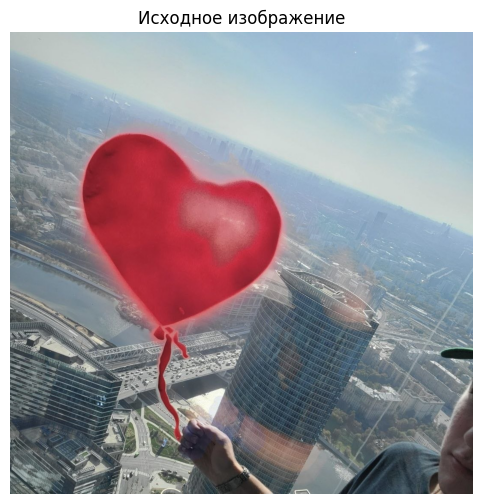

In [ ]:
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        if cmap is None and len(images[i].shape) == 3:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(images[i], cmap='gray' if cmap is None else cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
img_path = 'red_heart.jpg'
img = cv2.imread(img_path)


print(f"Изображение загружено, размер: {img.shape}")
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Исходное изображение")

plt.axis('off')
plt.show()

# Создание маски (Морфология + Цветовой фильтр)

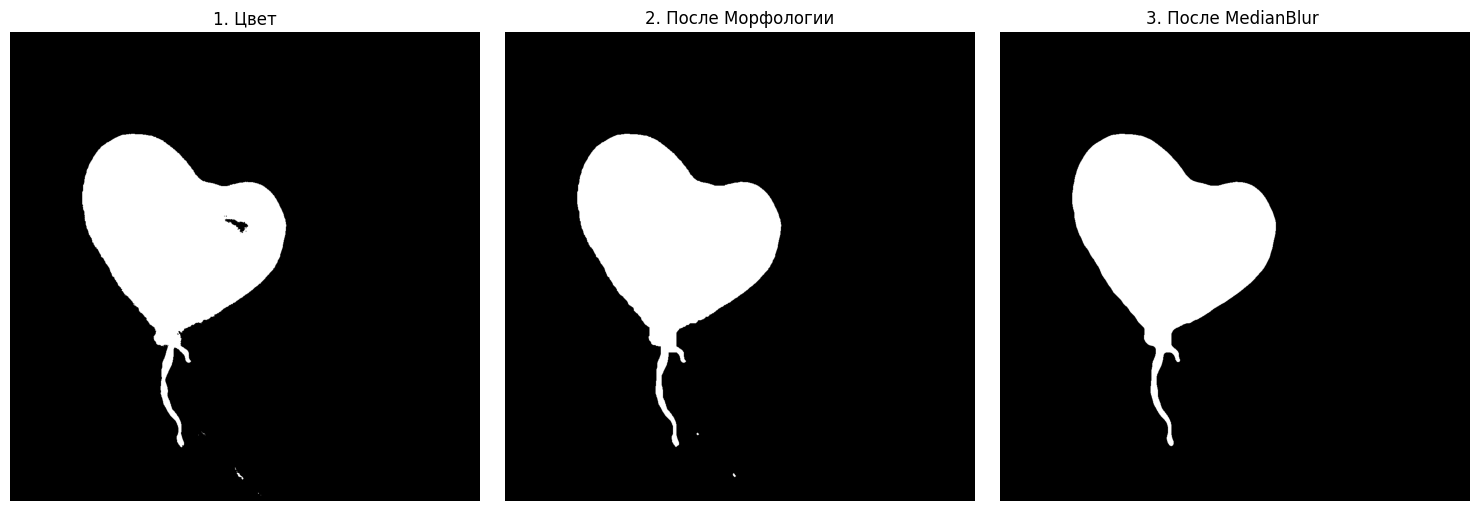

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # оттенок, насыщенность, яркость

lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
base_mask = cv2.bitwise_or(mask1, mask2)

kernel_close = np.ones((7, 7), np.uint8)
morph_mask = cv2.morphologyEx(base_mask, cv2.MORPH_CLOSE, kernel_close, iterations=3)


kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean_mask = cv2.morphologyEx(morph_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)


perfect_mask = cv2.medianBlur(clean_mask, 11)

show_images(
    [base_mask, clean_mask, perfect_mask], 
    ["1. Цвет", "2. После Морфологии", "3. После MedianBlur "]
)

final_mask = perfect_mask.copy()

# Метод GrabCut и сравнение

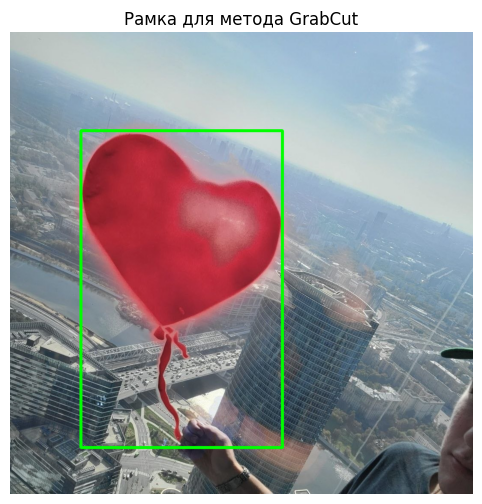

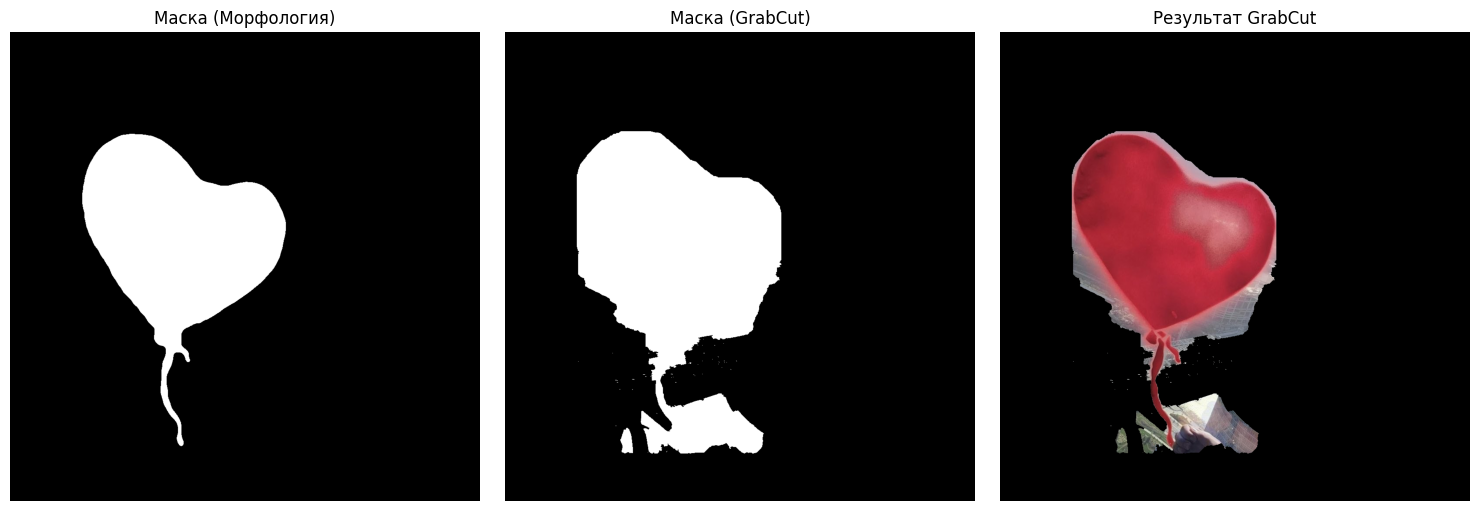

In [ ]:

x, y, w, h = 165, 230, 470, 740
img_1 = img.copy()
cv2.rectangle(img_1, (x, y), (x + w, y + h), (0, 255, 0), 5)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB))
plt.title("Рамка для метода GrabCut")
plt.axis('off')
plt.show()

grabcut_mask = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

rect = (x, y, w, h)


cv2.grabCut(img, grabcut_mask, rect, bgdModel, fgdModel, 7, cv2.GC_INIT_WITH_RECT)


# фон - 0 или 2, а объект -  1 или 3.
grabcut_mask_final = np.where((grabcut_mask==2)|(grabcut_mask==0), 0, 1).astype('uint8')
grabcut_mask_final = grabcut_mask_final * 255

grabcut_result = cv2.bitwise_and(img, img, mask=grabcut_mask_final)

show_images(
    [final_mask, grabcut_mask_final, grabcut_result], 
    ["Маска (Морфология)", "Маска (GrabCut)", "Результат GrabCut"]
)

# Генератор аугментации

In [5]:
class AugmentationGenerator:
    def __init__(self, image, mask):
        self.image = image
        self.mask = mask

    def flip(self, img, msk):
        # Отражение по горизонтали
        return cv2.flip(img, 1), cv2.flip(msk, 1)

    def rotate(self, img, msk, max_angle=30):
        # Поворот
        angle = random.uniform(-max_angle, max_angle)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        
        rotated_img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        rotated_msk = cv2.warpAffine(msk, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        return rotated_img, rotated_msk

    def add_blur(self, img, msk):
        # Размытие
        ksize = random.choice([3, 5, 7])
        blurred_img = cv2.GaussianBlur(img, (ksize, ksize), 0)
        return blurred_img, msk

    def change_brightness(self, img, msk):
        # Изменение яркости
        value = random.randint(-50, 50)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)
        
        if value > 0:
            lim = 255 - value
            v[v > lim] = 255
            v[v <= lim] += value
        else:
            lim = -value
            v[v < lim] = 0
            v[v >= lim] -= -value
            
        final_hsv = cv2.merge((h, s, v))
        bright_img = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
        return bright_img, msk

    def get_random_augmented(self):
        img_aug = self.image.copy()
        msk_aug = self.mask.copy()

        if random.random() > 0.5:
            img_aug, msk_aug = self.flip(img_aug, msk_aug)
            
        if random.random() > 0.5:
            img_aug, msk_aug = self.rotate(img_aug, msk_aug)
            
        if random.random() > 0.5:
            img_aug, msk_aug = self.add_blur(img_aug, msk_aug)
            
        if random.random() > 0.5:
            img_aug, msk_aug = self.change_brightness(img_aug, msk_aug)

        return img_aug, msk_aug

# Создание датасета

In [6]:
output_dir_images = 'dataset/images'
output_dir_masks = 'dataset/masks'

os.makedirs(output_dir_images, exist_ok=True)
os.makedirs(output_dir_masks, exist_ok=True)

aug_gen = AugmentationGenerator(img, final_mask)

num_samples = 40 

for i in range(num_samples):
    aug_img, aug_mask = aug_gen.get_random_augmented()
    
    img_filename = os.path.join(output_dir_images, f'aug_image_{i:03d}.jpg')
    mask_filename = os.path.join(output_dir_masks, f'aug_mask_{i:03d}.png') 
    
    cv2.imwrite(img_filename, aug_img)
    cv2.imwrite(mask_filename, aug_mask)